# Assignment 3

Sports Analytics
Multi-Object Tracking (MOT) is a core visual ability that humans poses to perform kinetic tasks and coordinate other tasks. The AI community has recognized the importance of MOT via a series of competitions.

The assignment will give us the opportunity to apply probabilistic reasoning to sports analytics - a sizable market for AI.
 In this assignment the object classes are person and ball and we will demonstrate the ability to reason over time using Kalman Filters.

# Task 1: Faster RCNN
Process the video using a framework and implement object detection based on Faster-RCNN. You dont need to implement the detector from scratch but you need to incorporate the source code in your implementation in a form of a notebook that will explain all the steps of the Faster-RCNN algorithm. Ensure that all explanations are included in markdown cells and stages are clearly labels with headlines. Explanation will be considered complete when visualizations of the output of each block are provided as shown in the video(s) below.

For demonstrating the object detection stages/blocks the video frames mush be processed (you can show your work using one of the many frames).

Please note that both ball and person are included in the COCO dataset and you can use a pretrained on COCO backbone such as shown in here.

In [ ]:
# first of all we install the dependencies
!pip install torch torchvision opencv-python yt-dlp


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import yt_dlp
import cv2
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Download video using yt-dlp
url = "https://www.youtube.com/watch?v=l3NJNFmg09k"
ydl_opts = {'format': 'best'}
with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([url])

[youtube] Extracting URL: https://www.youtube.com/watch?v=l3NJNFmg09k
[youtube] l3NJNFmg09k: Downloading webpage
[youtube] l3NJNFmg09k: Downloading ios player API JSON
[youtube] l3NJNFmg09k: Downloading mweb player API JSON
[youtube] l3NJNFmg09k: Downloading m3u8 information
[info] l3NJNFmg09k: Downloading 1 format(s): 18
[download] Football match [l3NJNFmg09k].mp4 has already been downloaded
[download] 100% of    3.57MiB


In [ ]:
# Using cuda because nvidia is good
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Here we load the pretrained model
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)
model.to(device)
model.eval()

# COCO dataset class names
COCO_CLASSES = weights.meta["categories"]

In [ ]:
def process_frame(frame):
    # Here we convert the  BGR to RGB (OpenCV uses BGR by default, PIL and other libraries use RGB)
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Convert the numpy array (rgb_frame) to a PIL Image, which is the expected format for many image processing libraries
    pil_image = Image.fromarray(rgb_frame)
    
    # Now we will be appluong  the necessary transformations (such as resizing, normalization, etc.) to the image for model compatibility
    transform = weights.transforms()  # Get the transformation pipeline
    transformed_image = transform(pil_image).to(device)  # Apply the transformations and move the image to the selected device (GPU or CPU)
    
    # Get predictions from the model, ensuring that no gradients are computed (for inference purposes)
    with torch.no_grad():  # No gradient tracking since this is just inference
        prediction = model([transformed_image])  # Pass the transformed image through the model for prediction
    
    # Return the model's prediction and the original frame in RGB format (for potential visualization or further processing)
    return prediction[0], rgb_frame


In [ ]:
def visualize_feature_maps(frame, model):
    # Get backbone feature maps
    backbone = model.backbone
    transformed_image = weights.transforms()(Image.fromarray(frame)).to(device)
    
    # Add detach() before converting to numpy
    with torch.no_grad():  # This ensures no gradients are computed
        features = backbone(transformed_image.unsqueeze(0))
        feature_map = features['0'].squeeze().cpu().detach().numpy()
    
    # Visualize first few feature maps
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    for idx, ax in enumerate(axes.flat):
        if idx < 16:
            ax.imshow(feature_map[idx], cmap='viridis')
            ax.axis('off')
    plt.tight_layout()
    plt.show()

def visualize_rpn_proposals(prediction):
    boxes = prediction['boxes'].cpu().numpy()
    scores = prediction['scores'].cpu().numpy()
    
    # Show top proposals
    return boxes[scores > 0.5]

def draw_detections(frame, prediction, threshold=0.5):
    boxes = prediction['boxes'].cpu().numpy()
    scores = prediction['scores'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()
    
    # Draw boxes for detections above threshold
    result_frame = frame.copy()
    for box, score, label in zip(boxes, scores, labels):
        if score > threshold:
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(result_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            label_text = f"{COCO_CLASSES[label]}: {score:.2f}"
            cv2.putText(result_frame, label_text, (x1, y1-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    return result_frame

Backbone Feature Maps:


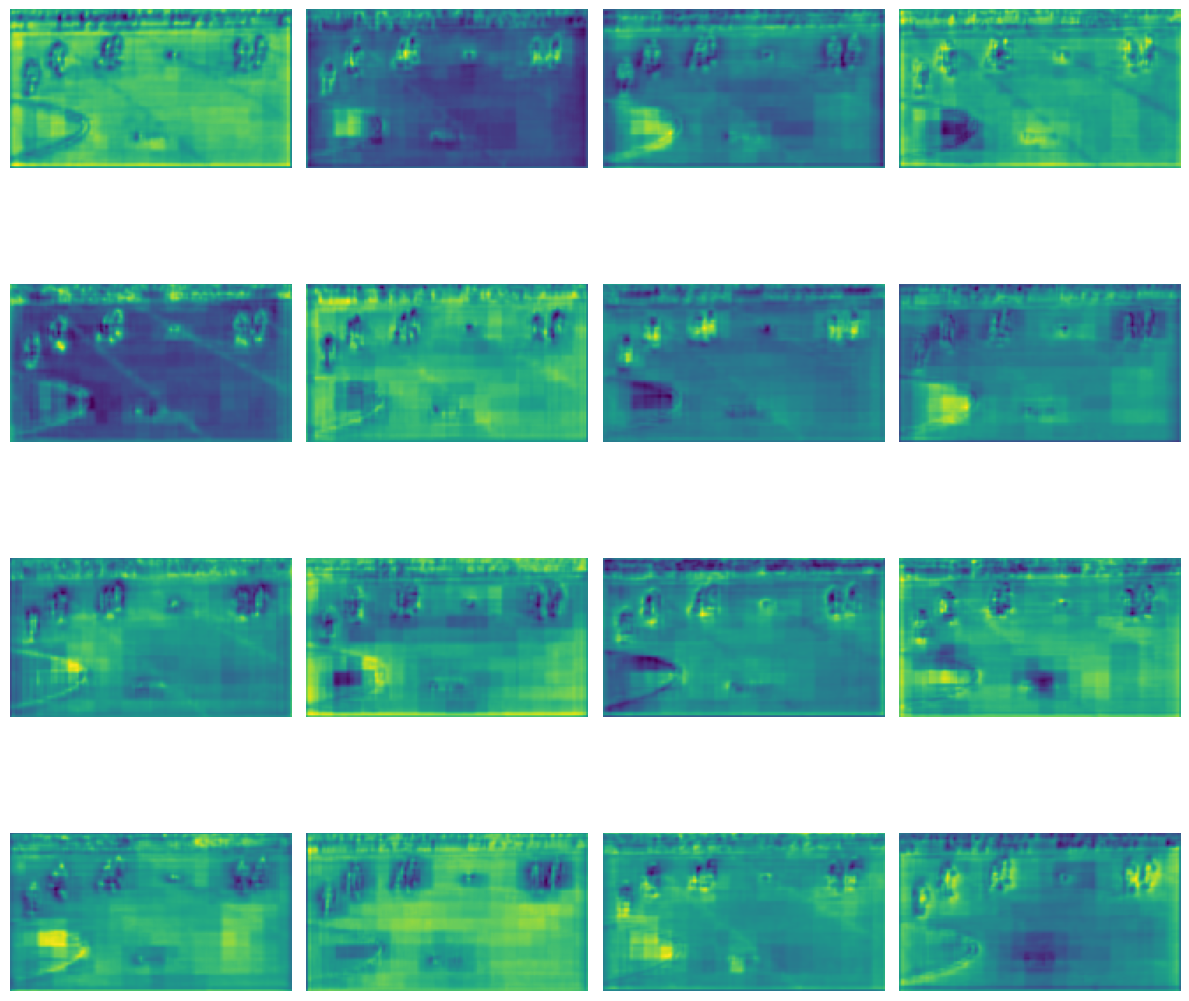

Region Proposals:
Final Detections:


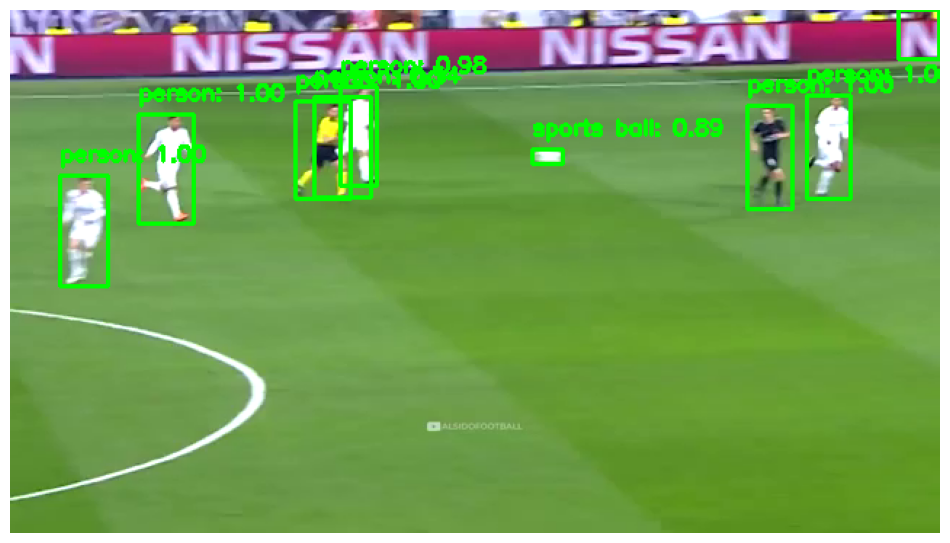

In [ ]:
# Open video file for processing
cap = cv2.VideoCapture('football.mp4')  # Open the video file 'football.mp4' for reading frames

# Process a single frame for demonstration
ret, frame = cap.read()  # Read the first frame from the video
if ret:  # If a frame is successfully read
    # Get predictions for the frame using a model (process_frame handles transformations and inference)
    prediction, rgb_frame = process_frame(frame)
    
    # 1. Visualize backbone feature maps from the model's backbone (used for detecting features in the image)
    print("Backbone Feature Maps:")  
    visualize_feature_maps(rgb_frame, model)  # Visualize feature maps (e.g., first layer outputs)
    
    # 2. Visualize Region Proposal Network (RPN) proposals based on the model's prediction scores
    print("Region Proposals:")  
    proposals = visualize_rpn_proposals(prediction)  # Get and visualize high-scoring RPN proposals
    
    # 3. Show final detections: Draw bounding boxes on the frame for the final detections
    print("Final Detections:")  
    result = draw_detections(rgb_frame, prediction)  # Draw bounding boxes for detected objects on the frame
    
    # Display the frame with detections using matplotlib
    plt.figure(figsize=(12, 8))  # Set the size of the display
    plt.imshow(result)  # Show the result with detections
    plt.axis('off')  # Turn off axis labels for cleaner display
    plt.show()  # Render the image with detections
    
# Release the video capture object
cap.release()  # Close the video file after processing


In [ ]:
def process_video(input_path, output_path):
    # Open the input video file for reading frames
    cap = cv2.VideoCapture(input_path)
    
    # Get video properties: frame width, height, and frames per second (FPS)
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))  # Get the width of the video frame
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))  # Get the height of the video frame
    fps = int(cap.get(cv2.CAP_PROP_FPS))  # Get the FPS of the video
    
    # Initialize the output video writer (to save processed frames)
    out = cv2.VideoWriter(output_path, 
                         cv2.VideoWriter_fourcc(*'mp4v'),  # Video codec (MP4 format)
                         fps,  # Frames per second (same as input)
                         (frame_width, frame_height))  # Size of the output video
    
    # Loop through all frames in the video
    while cap.isOpened():
        ret, frame = cap.read()  # Read a frame from the video
        if not ret:  # If no frame is read (end of video), break the loop
            break
            
        # Process the frame to get predictions (e.g., bounding boxes, labels, etc.)
        prediction, rgb_frame = process_frame(frame)
        
        # Draw the bounding boxes and labels on the frame (detection results)
        result_frame = draw_detections(rgb_frame, prediction)
        
        # Convert the processed frame from RGB back to BGR (since OpenCV uses BGR color format)
        result_frame = cv2.cvtColor(result_frame, cv2.COLOR_RGB2BGR)
        
        # Write the processed frame to the output video file
        out.write(result_frame)
    
    # Release the video capture and writer objects to free up resources
    cap.release()
    out.release()

# Finally we call the function to process and save the output video
process_video('football.mp4', 'task1_video_output.mp4')


# Task 1: Deep-SORT

# Object Tracking System Architecture
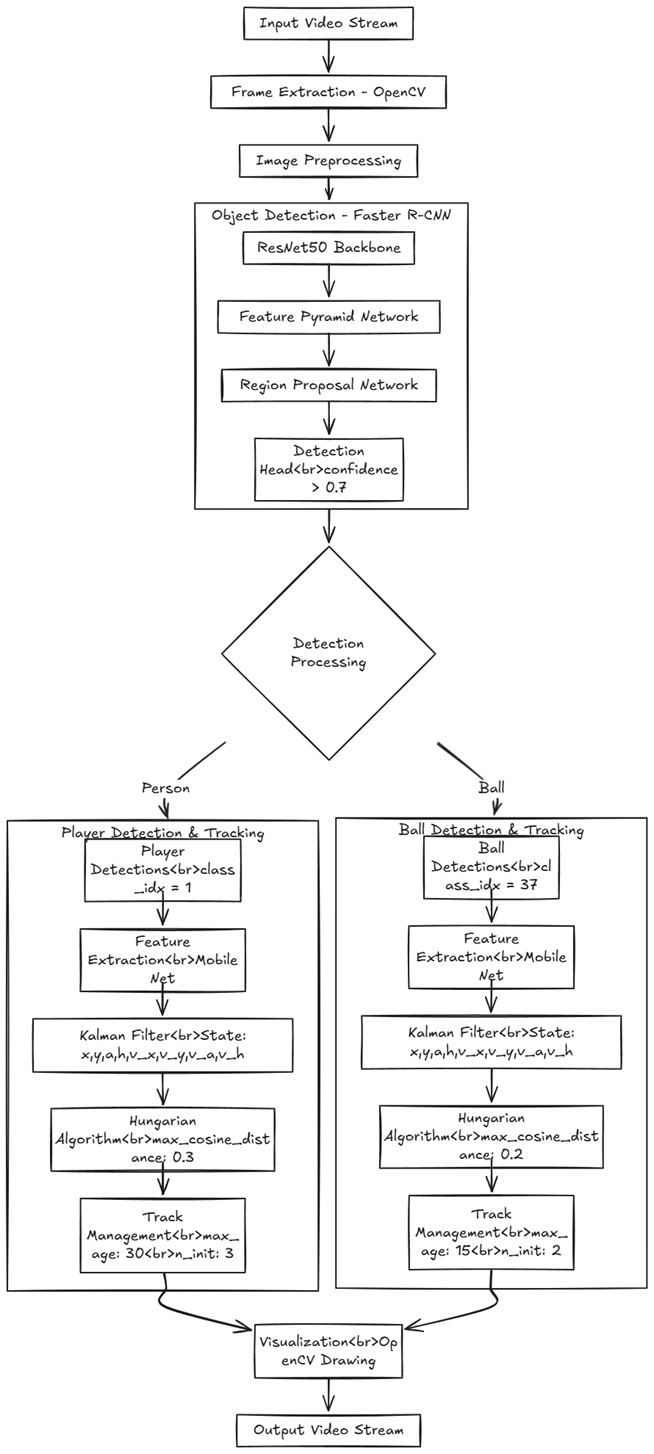
## Architecture Overview

The system consists of three main processing stages:
1. Input Processing
2. Detection Pipeline
3. Parallel Tracking Systems

## Key Components Breakdown

### Input Processing
- Video stream input
- Frame extraction using OpenCV
- Image preprocessing for neural network compatibility

### Detection Pipeline (Faster R-CNN)
- ResNet50 backbone for feature extraction
- Feature Pyramid Network for multi-scale features
- Region Proposal Network for object candidates
- Detection head with confidence threshold > 0.7

### Parallel Tracking Systems

**1. Player Tracking (class_idx = 1)**
- MobileNet feature extraction
- Kalman filtering
- Hungarian matching (max_cosine_distance = 0.3)
- Track management (max_age = 30, n_init = 3)

**2. Ball Tracking (class_idx = 37)**
- Similar structure but with different parameters
- More sensitive tracking (max_cosine_distance = 0.2)
- Shorter track lifetime (max_age = 15, n_init = 2)

## Kalman Filter Equations

The Kalman filter uses an 8-dimensional state vector:
$$ x = [x, y, a, h, v_x, v_y, v_a, v_h]^T $$
where:
- (x,y): center position
- a: aspect ratio
- h: height
- v_x, v_y, v_a, v_h: respective velocities

**Key equations:**

1. Prediction:
$$ \hat{x}_k = F\hat{x}_{k-1} $$
$$ P_k = FP_{k-1}F^T + Q $$

2. Update:
$$ K = P_kH^T(HP_kH^T + R)^{-1} $$
$$ \hat{x}_k = \hat{x}_k + K(z_k - H\hat{x}_k) $$
$$ P_k = (I - KH)P_k $$

## Hungarian Algorithm

The Hungarian Algorithm solves the assignment problem between detections and existing tracks:

### Process Flow
1. Creates a cost matrix where:
   - Rows represent existing tracks
   - Columns represent new detections
   - Elements are combined costs from:
     - Mahalanobis distance (motion)
     - Feature similarity (appearance)

2. Finds optimal assignment by:
   - Converting to minimization problem
   - Applying row/column reductions
   - Finding minimum set of lines covering zeros
   - Iteratively adjusting matrix until optimal solution found

### Output
- Optimal track-to-detection assignments
- Minimizes total assignment cost
- Handles unmatched tracks and detections

The algorithm ensures each track is assigned to at most one detection and vice versa, while minimizing the overall cost of assignments.

# Here we will be going through the code and how kalman filters and hungarian algorithm is used.

This code is designed to track objects (specifically players and a ball) in a video using deep learning-based object detection and tracking. It combines the **Faster R-CNN** model for object detection and the **DeepSORT** algorithm for tracking. Let's break down the key components and explain how **Kalman filters** and the **Hungarian algorithm** are used within the DeepSORT tracker.



### ObjectTracker Class:

**Purpose**:  
The `ObjectTracker` class is responsible for detecting objects (players and the ball) in a video frame and then tracking them across frames.

#### Initialization (`__init__`):
- The class sets up a `cuda` device (if available) and initializes the Faster R-CNN object detection model (`fasterrcnn_resnet50_fpn`), which is trained to detect objects like people and sports balls.
- Two instances of the **DeepSort** tracker are created: one for players and another for the ball. These trackers handle tracking the objects across video frames.

#### Detect Objects (`detect_objects`):
- This method takes an input frame, processes it through Faster R-CNN, and filters out detections based on class labels and confidence scores (e.g., people or balls).
- Player and ball detections are handled separately to fine-tune detection parameters for each class.

#### Update Tracks (`update_tracks`):
- This method feeds the object detections into the **DeepSort** tracker, which updates the state of each tracked object (player or ball).
- The tracker uses the **Kalman filter** and the **Hungarian algorithm** to maintain consistent tracking IDs across frames.

### DeepSort Tracker:


### Main Video Processing (`process_video`):

- This function processes the video frame by frame, calling `detect_objects` and `update_tracks` to detect and track the players and ball.
- It draws bounding boxes around tracked objects and labels them (e.g., "Player 1", "Ball").
- The processed video is saved to a new file, and optionally displayed during processing.

## Kalman Filter and Hungarian Algorithm in the Code:

### Kalman Filter:
- The Kalman filter is used internally by the **DeepSort** tracker. It helps in maintaining the identity of each object (player or ball) even when the object is temporarily occluded or moves in a non-linear manner.
- It works by predicting the future location of each object based on its past trajectory and adjusting the estimate when new observations (detections) are available.
- In this implementation, the Kalman filter is part of the **DeepSort** tracking process, but it's not explicitly visible in the code as it is encapsulated in the **DeepSort** object.

### Hungarian Algorithm:
- The **Hungarian algorithm** is used in **DeepSort** to solve the data association problem. When new detections are made, the algorithm matches them to the existing tracks by minimizing the matching cost (usually based on the Euclidean distance between the predicted location of a track and the detected object).
- This process ensures that each object is consistently tracked across frames, even if there are multiple objects or some detections are missing.


In [63]:
import cv2
import torch
import numpy as np
from PIL import Image
from deep_sort_realtime.deepsort_tracker import DeepSort
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

class ObjectTracker:
    def __init__(self, device):
        cuda_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {cuda_device}")
        self.device = cuda_device
        print(f"Initializing ObjectTracker on: {self.device}")
        
        # Initialize Faster R-CNN with improved weights for object detection
        weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
        self.model = fasterrcnn_resnet50_fpn(weights=weights, box_score_thresh=0.7)
        self.model.to(self.device)
        self.model.eval()
        
        # Initialize separate trackers for players and ball
        self.player_tracker = DeepSort(
            max_age=30,  # Tracks player objects for up to 30 frames
            n_init=3,    # Number of initial detections required to start a track
            nms_max_overlap=1.0,  # Non-Maximum Suppression overlap threshold
            max_cosine_distance=0.3,  # Distance threshold for track matching (via Hungarian algorithm)
            embedder="mobilenet",  # Feature extractor for appearance-based matching
            half=True,  # Use half precision for faster processing
            bgr=True,  # Input image format (BGR)
            embedder_gpu=True if self.device == 'cuda' else False  # Use GPU if available
        )
        
        self.ball_tracker = DeepSort(
            max_age=15,  # Tracks ball objects for fewer frames due to frequent occlusion
            n_init=2,    # Requires fewer initial detections for ball
            nms_max_overlap=1.0,
            max_cosine_distance=0.2,  # Stricter matching for ball
            embedder="mobilenet",
            half=True,
            bgr=True,
            embedder_gpu=True if self.device == 'cuda' else False
        )
        
        self.person_class_idx = 1  # COCO class index for people
        self.ball_class_idx = 37   # COCO class index for sports balls
        self.transforms = weights.transforms()  # Image preprocessing pipeline for Faster R-CNN
        
    def detect_objects(self, frame):
        # Preprocess the frame for object detection
        img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img)
        img_tensor = self.transforms(img_pil).to(self.device)
        
        with torch.no_grad():
            predictions = self.model([img_tensor])  # Perform detection
        
        # Separate detections for players and ball
        player_detections = []
        ball_detections = []
        
        # Get bounding boxes, scores, and labels from Faster R-CNN predictions
        boxes = predictions[0]['boxes'].cpu().numpy()
        scores = predictions[0]['scores'].cpu().numpy()
        labels = predictions[0]['labels'].cpu().numpy()
        
        # Filter detections based on class (player or ball) and score threshold
        for box, score, label in zip(boxes, scores, labels):
            if score > 0.7:  # Filter detections with low confidence
                x1, y1, x2, y2 = box.astype(np.float32)
                w = x2 - x1
                h = y2 - y1
                
                if label == self.person_class_idx:
                    player_detections.append([[x1, y1, w, h], score, label])
                elif label == self.ball_class_idx:
                    # Filter ball detections based on aspect ratio and size
                    aspect_ratio = w / h
                    if 0.5 < aspect_ratio < 2.0 and w < frame.shape[1] / 4:
                        ball_detections.append([[x1, y1, w, h], score, label])
        
        return player_detections, ball_detections
    
    def update_tracks(self, frame, player_detections, ball_detections):
        # Update the object trackers with the new detections
        player_tracks = self.player_tracker.update_tracks(player_detections, frame=frame)
        ball_tracks = self.ball_tracker.update_tracks(ball_detections, frame=frame)
        return player_tracks, ball_tracks

def process_video(input_path, output_path, show_display=False):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    tracker = ObjectTracker(device=device)
    
    cap = cv2.VideoCapture(input_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    
    out = cv2.VideoWriter(output_path,
                         cv2.VideoWriter_fourcc(*'mp4v'),
                         fps,
                         (width, height))
    
    frame_count = 0
    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            
            # Detect objects in the frame
            player_detections, ball_detections = tracker.detect_objects(frame)
            
            # Update object tracks
            player_tracks, ball_tracks = tracker.update_tracks(frame, player_detections, ball_detections)
            
            # Draw player tracks
            for track in player_tracks:
                if not track.is_confirmed():
                    continue
                
                ltrb = track.to_ltrb()
                x1, y1, x2, y2 = map(int, ltrb)
                
                # Draw bounding box for player
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, f"Player {track.track_id}", (x1, y1-10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            
            # Draw ball tracks
            for track in ball_tracks:
                if not track.is_confirmed():
                    continue
                
                ltrb = track.to_ltrb()
                x1, y1, x2, y2 = map(int, ltrb)
                
                # Draw bounding box for ball
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
                cv2.putText(frame, "Ball", (x1, y1-10),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
            
            out.write(frame)  # Save the processed frame
            
            # Optionally display the frame
            if show_display:
                try:
                    cv2.imshow('Tracking', frame)
                    if cv2.waitKey(1) & 0xFF == ord('q'):
                        break
                except cv2.error:
                    print("Display not available, continuing without visualization")
                    show_display = False
            
            frame_count += 1
            if frame_count % 30 == 0:
                print(f"Processed {frame_count} frames")
    
    finally:
        cap.release()
        out.release()
        if show_display:
            cv2.destroyAllWindows()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# Run the tracking on an input video
input_video = 'football.mp4'
output_video = 'task2_football_output.mp4'
process_video(input_video, output_video, show_display=False)


Using device: cuda
Initializing ObjectTracker on: cuda
Processed 30 frames
Processed 60 frames
Processed 90 frames
Processed 120 frames
Processed 150 frames
Processed 180 frames
Processed 210 frames
Processed 240 frames
Processed 270 frames
Processed 300 frames
Processed 330 frames
Processed 360 frames
Processed 390 frames
Processed 420 frames
Processed 450 frames
Processed 480 frames
Processed 510 frames
Processed 540 frames
Processed 570 frames
Processed 600 frames
Processed 630 frames
Processed 660 frames
Processed 690 frames
Processed 720 frames
Processed 750 frames
Processed 780 frames
Processed 810 frames
Processed 840 frames
Processed 870 frames
Processed 900 frames
Processed 930 frames
Processed 960 frames
Processed 990 frames
Processed 1020 frames
Processed 1050 frames
